/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 169MB/s]


Epoch 1/10
--------------------
train Loss: 0.3582 Acc: 0.9074
val Loss: 0.0032 Acc: 1.0000

Epoch 2/10
--------------------
train Loss: 0.0323 Acc: 0.9924
val Loss: 0.0011 Acc: 1.0000

Epoch 3/10
--------------------
train Loss: 0.0407 Acc: 0.9914
val Loss: 0.0005 Acc: 1.0000

Epoch 4/10
--------------------
train Loss: 0.0139 Acc: 0.9952
val Loss: 0.0009 Acc: 1.0000

Epoch 5/10
--------------------
train Loss: 0.0231 Acc: 0.9914
val Loss: 0.0011 Acc: 1.0000

Epoch 6/10
--------------------
train Loss: 0.0160 Acc: 0.9943
val Loss: 0.0002 Acc: 1.0000

Epoch 7/10
--------------------
train Loss: 0.0046 Acc: 0.9990
val Loss: 0.0001 Acc: 1.0000

Epoch 8/10
--------------------
train Loss: 0.0012 Acc: 1.0000
val Loss: 0.0001 Acc: 1.0000

Epoch 9/10
--------------------
train Loss: 0.0285 Acc: 0.9885
val Loss: 0.0545 Acc: 0.9867

Epoch 10/10
--------------------
train Loss: 0.0245 Acc: 0.9943
val Loss: 0.0009 Acc: 1.0000

Test Loss: 0.0010, Test Accuracy: 1.0000
F1 Score: 1.0000, Precision:

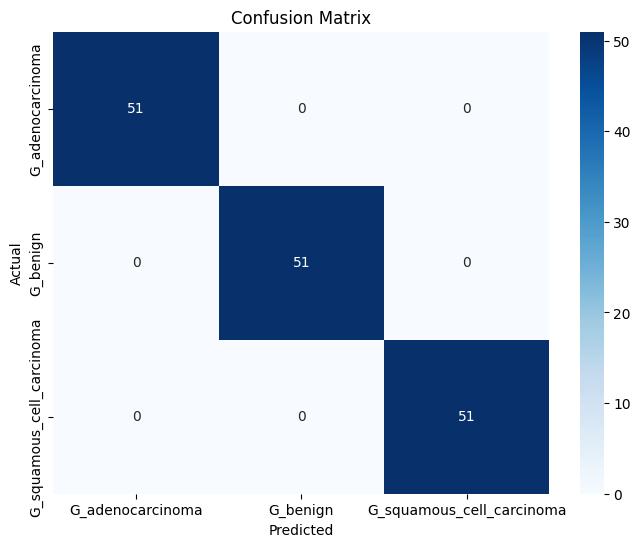

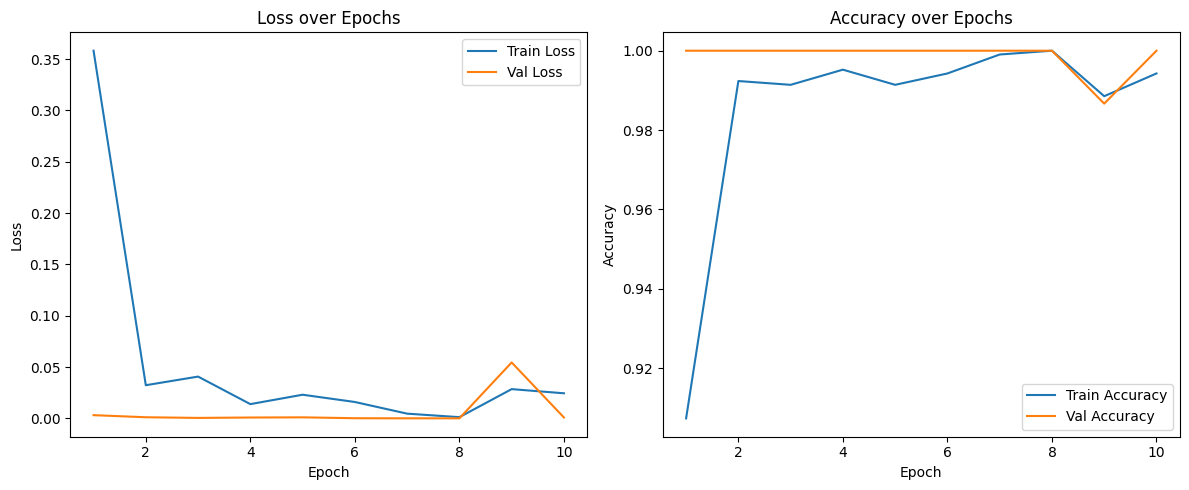

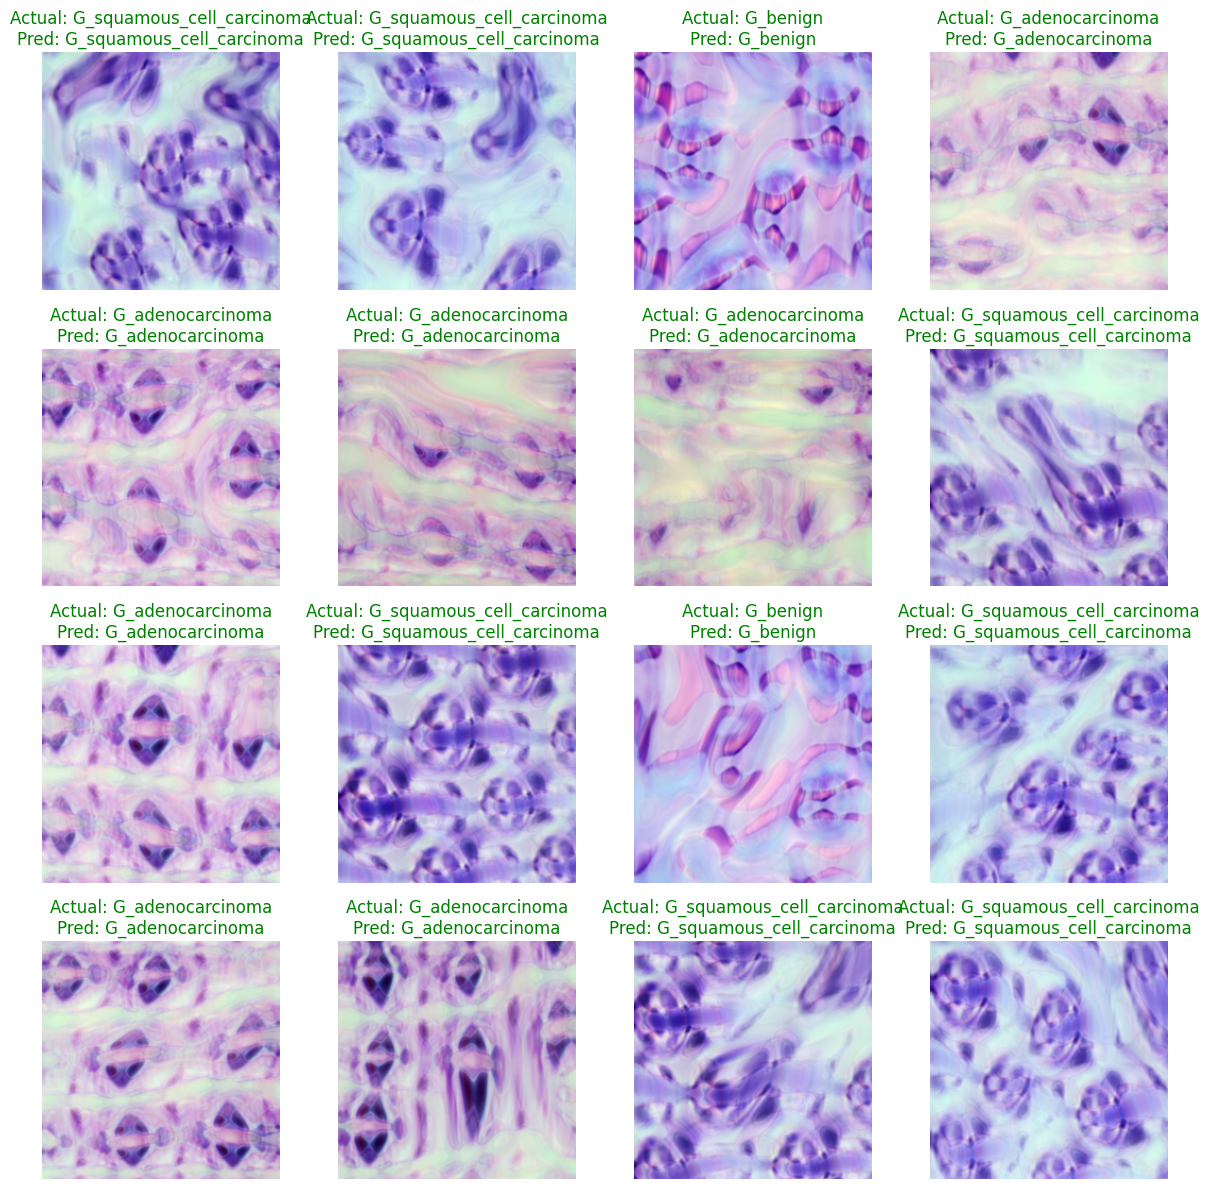

In [1]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, classification_report, accuracy_score, precision_score, recall_score
import seaborn as sns

# ------------------------------
# Data Preparation and Splitting
# ------------------------------

# Set data directories (adjust paths as needed)
data_dir = '/kaggle/input/dcgan-images/dcgan_generated_images'
train_dir = '/kaggle/working/train'
val_dir   = '/kaggle/working/val'
test_dir  = '/kaggle/working/test'

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Define class names
classes = ['G_adenocarcinoma', 'G_benign', 'G_squamous_cell_carcinoma']
for subfolder in classes:
    os.makedirs(os.path.join(train_dir, subfolder), exist_ok=True)
    os.makedirs(os.path.join(val_dir, subfolder), exist_ok=True)
    os.makedirs(os.path.join(test_dir, subfolder), exist_ok=True)

def split_data(source_dir, train_dir, val_dir, test_dir, val_size=0.2, test_size=0.1):
    for label in classes:
        files = os.listdir(os.path.join(source_dir, label))
        train_files, val_test_files = train_test_split(files, test_size=val_size + test_size, random_state=42)
        val_files, test_files = train_test_split(val_test_files, test_size=test_size / (val_size + test_size), random_state=42)
        for file in train_files:
            shutil.copy(os.path.join(source_dir, label, file), os.path.join(train_dir, label, file))
        for file in val_files:
            shutil.copy(os.path.join(source_dir, label, file), os.path.join(val_dir, label, file))
        for file in test_files:
            shutil.copy(os.path.join(source_dir, label, file), os.path.join(test_dir, label, file))

# Run once to split the dataset
split_data(data_dir, train_dir, val_dir, test_dir)

# ------------------------------
# Data Transforms and Dataloaders
# ------------------------------

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val']),
    'test': datasets.ImageFolder(test_dir, data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False),
    'test': DataLoader(image_datasets['test'], batch_size=32, shuffle=False)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

# ------------------------------
# Helper Functions for Swin Transformer
# ------------------------------

def window_partition(x, window_size):
    """
    Partition input x into non-overlapping windows.
    x: (B, H, W, C)
    Returns: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    """
    Reconstruct feature map from windows.
    windows: (num_windows*B, window_size, window_size, C)
    Returns: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

# ------------------------------
# Simplified Swin Transformer Components
# ------------------------------

class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        """
        dim: input dimension
        window_size: int, window size (assumed square)
        num_heads: number of attention heads
        """
        super(WindowAttention, self).__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        
    def forward(self, x):
        """
        x: (B*num_windows, window_area, dim)
        """
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B_, num_heads, N, C//num_heads)
        q, k, v = qkv[0], qkv[1], qkv[2]   # each: (B_, num_heads, N, C//num_heads)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B_, num_heads, N, N)
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop=0.):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(drop)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=7, mlp_ratio=4.0, drop=0.):
        super(SwinTransformerBlock, self).__init__()
        self.window_size = window_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), drop=drop)
        
    def forward(self, x, H, W):
        """
        x: (B, L, dim) where L = H*W
        """
        shortcut = x
        x = self.norm1(x)
        B, L, C = x.shape
        x = x.view(B, H, W, C)
        
        # Partition windows
        windows = window_partition(x, self.window_size)  # (num_windows*B, window_size, window_size, C)
        windows = windows.view(-1, self.window_size * self.window_size, C)  # (num_windows*B, window_area, C)
        
        # Apply window-based multi-head self-attention
        attn_windows = self.attn(windows)  # (num_windows*B, window_area, C)
        
        # Merge windows back to feature map
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, H, W)  # (B, H, W, C)
        x = x.view(B, L, C)
        
        # Skip connection and MLP
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x

# ------------------------------
# Hybrid Model: DenseNet + Swin Transformer
# ------------------------------

class HybridDenseSwin(nn.Module):
    def __init__(self, num_classes, d_model=512, num_swin_blocks=2, window_size=7, num_heads=8):
        super(HybridDenseSwin, self).__init__()
        # Load DenseNet-121 backbone (optionally pretrained)
        densenet = models.densenet121(pretrained=True)
        self.backbone = densenet.features  # Output feature maps; DenseNet-121 output channels = 1024 for 224 input
        # Project feature maps to d_model channels
        self.project = nn.Conv2d(1024, d_model, kernel_size=1)
        
        self.num_swin_blocks = num_swin_blocks
        self.swin_blocks = nn.ModuleList([
            SwinTransformerBlock(dim=d_model, num_heads=num_heads, window_size=window_size)
            for _ in range(num_swin_blocks)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        # x: (B, 3, 224, 224)
        x = self.backbone(x)   # (B, 1024, H, W); for DenseNet-121 with 224 input, H and W ~7
        x = self.project(x)    # (B, d_model, H, W)
        B, C, H, W = x.shape
        # Flatten spatial dimensions: (B, H*W, d_model)
        x = x.flatten(2).transpose(1, 2)
        for blk in self.swin_blocks:
            x = blk(x, H, W)
        x = self.norm(x)
        # Global average pooling over tokens
        x = x.mean(dim=1)
        x = self.classifier(x)
        return x

# ------------------------------
# Training and Evaluation Setup
# ------------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(class_names)
model = HybridDenseSwin(num_classes=num_classes, d_model=512, num_swin_blocks=2, window_size=7, num_heads=8).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Variable to control number of epochs explicitly
num_epochs = 10

# For tracking training history
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

def train_model(model, criterion, optimizer, num_epochs):
    best_acc = 0.0
    best_model_wts = None
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            
            running_loss = 0.0
            running_corrects = 0
            
            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.item())
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())
                # Save best model weights
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = model.state_dict()
        print()
    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    test_loss = running_loss / dataset_sizes['test']
    test_acc  = running_corrects.double() / dataset_sizes['test']
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
    
    # Calculate additional scores
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    print(f'F1 Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
    
    return test_loss, test_acc

# ------------------------------
# Train and Evaluate the Model
# ------------------------------

model = train_model(model, criterion, optimizer, num_epochs)
evaluate_model(model, criterion)

# ------------------------------
# Plot Training Graphs
# ------------------------------

epochs_range = range(1, num_epochs+1)
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_history, label="Train Loss")
plt.plot(epochs_range, val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_history, label="Train Accuracy")
plt.plot(epochs_range, val_acc_history, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------
# Function to Visualize Random Test Predictions
# ------------------------------

def show_random_test_predictions(model, dataloader, class_names, num_images=16):
    model.eval()
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    
    all_images = []
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_images.extend(inputs.cpu())
            all_labels.extend(labels.cpu())
            all_preds.extend(preds.cpu())
    
    combined = list(zip(all_images, all_labels, all_preds))
    random.shuffle(combined)
    selected_images = random.sample(combined, min(num_images, len(combined)))
    
    for idx, (img, label, pred) in enumerate(selected_images):
        ax = axes[idx]
        ax.axis('off')
        img = img.numpy().transpose((1, 2, 0))
        img = np.clip((img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])), 0, 1)
        ax.imshow(img)
        title = f'Actual: {class_names[label]}\nPred: {class_names[pred]}'
        ax.set_title(title, color='green' if class_names[label] == class_names[pred] else 'red')
    
    plt.tight_layout()
    plt.show()

# Visualize random test predictions
show_random_test_predictions(model, dataloaders['test'], class_names, num_images=16)


Train classes: ['G_adenocarcinoma', 'G_benign', 'G_squamous_cell_carcinoma']
Test  classes: ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
Sizes: {'train': 1200, 'val': 402, 'test': 15000}


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10
--------------------
train Loss: 0.3654 Acc: 0.9075
val Loss: 0.0079 Acc: 1.0000

Epoch 2/10
--------------------
train Loss: 0.0179 Acc: 0.9933
val Loss: 0.0004 Acc: 1.0000

Epoch 3/10
--------------------
train Loss: 0.0064 Acc: 0.9975
val Loss: 0.0004 Acc: 1.0000

Epoch 4/10
--------------------
train Loss: 0.0161 Acc: 0.9950
val Loss: 0.0004 Acc: 1.0000

Epoch 5/10
--------------------
train Loss: 0.0026 Acc: 0.9992
val Loss: 0.0002 Acc: 1.0000

Epoch 6/10
--------------------
train Loss: 0.0004 Acc: 1.0000
val Loss: 0.0001 Acc: 1.0000

Epoch 7/10
--------------------
train Loss: 0.0005 Acc: 1.0000
val Loss: 0.0001 Acc: 1.0000

Epoch 8/10
--------------------
train Loss: 0.0077 Acc: 0.9983
val Loss: 0.0001 Acc: 1.0000

Epoch 9/10
--------------------
train Loss: 0.0021 Acc: 0.9992
val Loss: 0.0001 Acc: 1.0000

Epoch 10/10
--------------------
train Loss: 0.0007 Acc: 1.0000
val Loss: 0.0001 Acc: 1.0000

Test Loss: 3.9271, Test Accuracy: 0.5697
F1 Score: 0.4955, Precision:

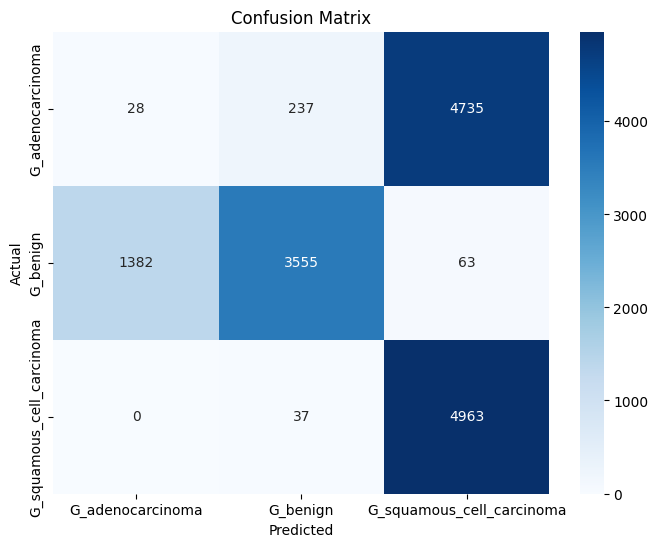

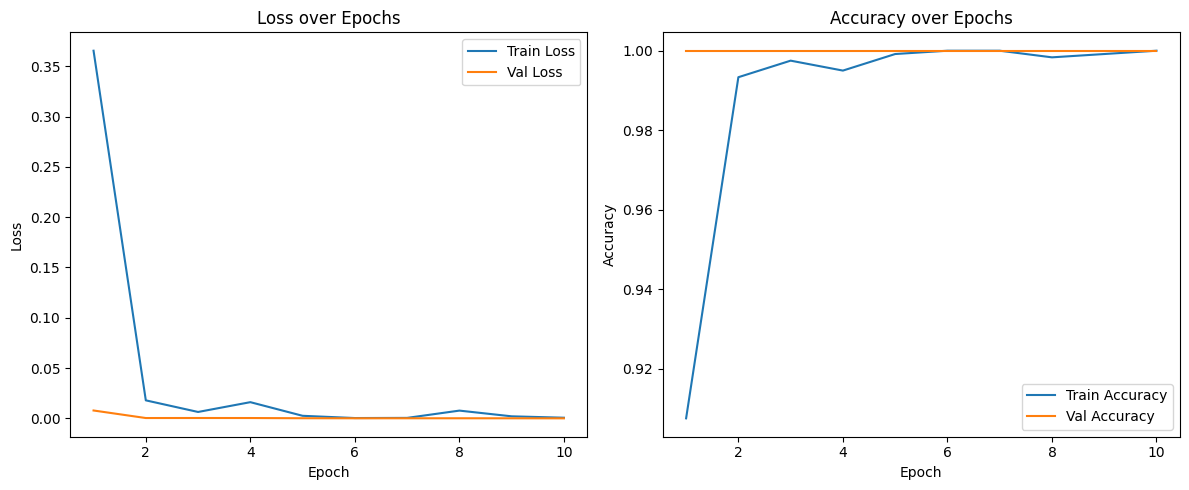

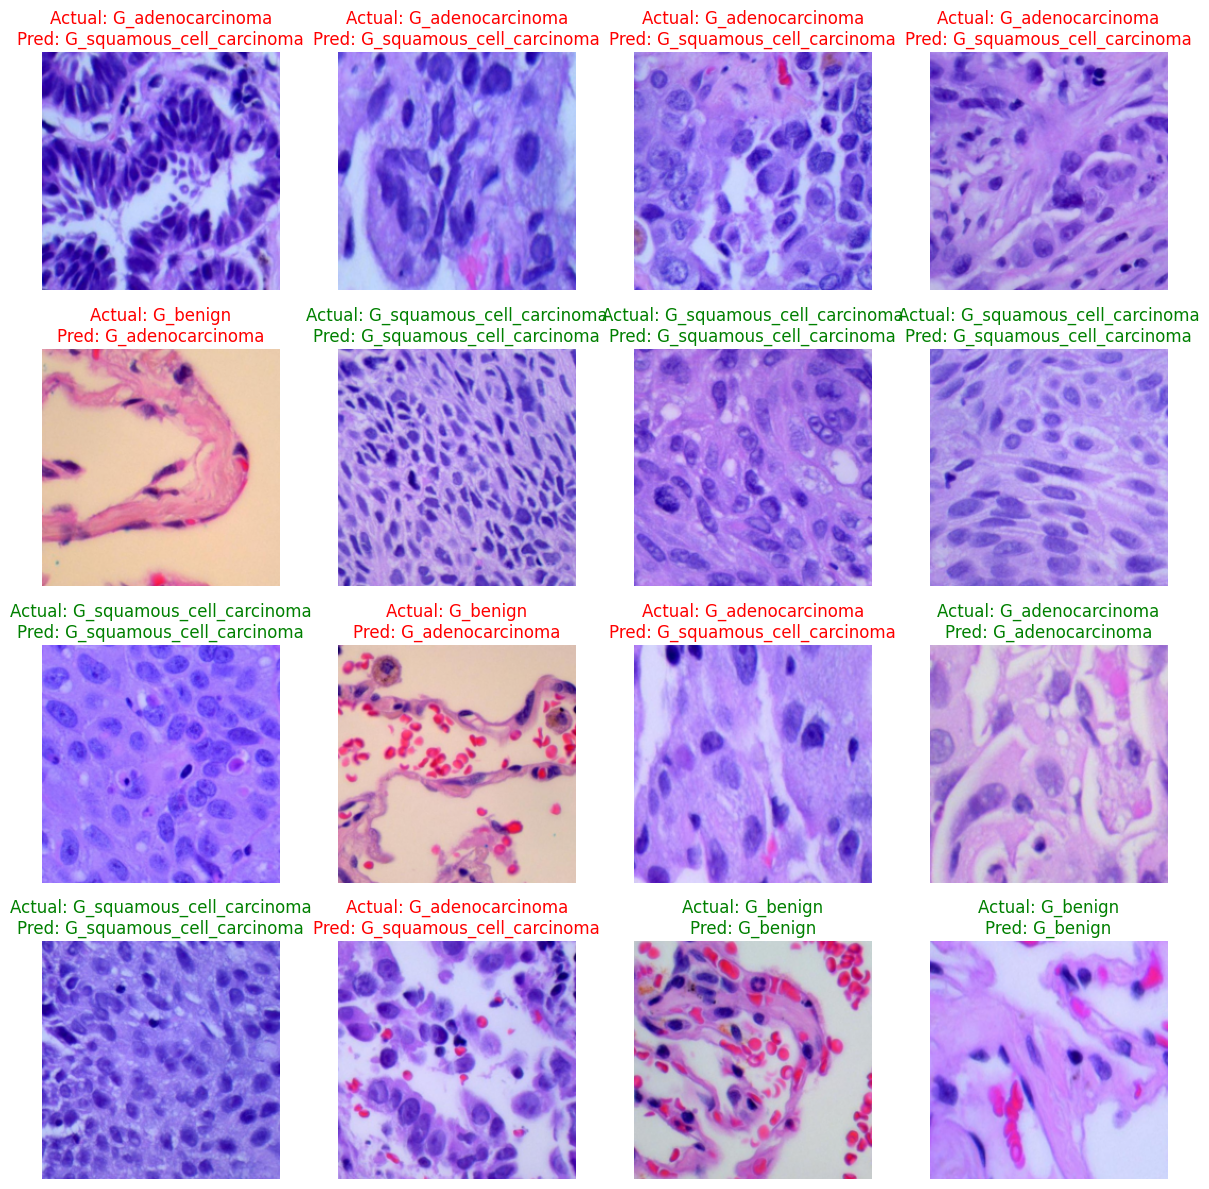

In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 1. Paths
gan_dir       = '/kaggle/input/dcgan-images/dcgan_generated_images'
real_dir      = '/kaggle/input/lung-cancer-histopathological-images'
work_dir      = '/kaggle/working'
train_dir     = os.path.join(work_dir, 'train')
val_dir       = os.path.join(work_dir, 'val')

# 2. Make train/val dirs for GAN images
classes = ['G_adenocarcinoma', 'G_benign', 'G_squamous_cell_carcinoma']
for d in [train_dir, val_dir]:
    for c in classes:
        os.makedirs(os.path.join(d, c), exist_ok=True)

# 3. Split GAN images (80/20) into train/val
def split_gan( src, train_dst, val_dst, val_frac=0.2, seed=42 ):
    for c in classes:
        imgs = os.listdir(os.path.join(src, c))
        train_imgs, val_imgs = train_test_split(imgs, test_size=val_frac, random_state=seed)
        for fn in train_imgs:
            shutil.copy(os.path.join(src, c, fn), os.path.join(train_dst, c, fn))
        for fn in val_imgs:
            shutil.copy(os.path.join(src, c, fn), os.path.join(val_dst, c, fn))

split_gan(gan_dir, train_dir, val_dir)

# 4. Transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
    # real test set gets the same transforms as val
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
}

# 5. Datasets & Loaders
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val'  : datasets.ImageFolder(val_dir,   data_transforms['val']),
    # point test at the real dataset (no G_ prefix in subfolders)
    'test' : datasets.ImageFolder(real_dir,  data_transforms['test'])
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32,
                  shuffle=(x=='train'))
    for x in ['train','val','test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train','val','test']}
class_names   = image_datasets['train'].classes   # ['G_adenocarcinoma',...]
test_names    = image_datasets['test'].classes    # ['adenocarcinoma',...]

print("Train classes:", class_names)
print("Test  classes:", test_names)
print("Sizes:", dataset_sizes)


# ------------------------------
# Helper Functions for Swin Transformer
# ------------------------------

def window_partition(x, window_size):
    """
    Partition input x into non-overlapping windows.
    x: (B, H, W, C)
    Returns: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    """
    Reconstruct feature map from windows.
    windows: (num_windows*B, window_size, window_size, C)
    Returns: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

# ------------------------------
# Simplified Swin Transformer Components
# ------------------------------

class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        """
        dim: input dimension
        window_size: int, window size (assumed square)
        num_heads: number of attention heads
        """
        super(WindowAttention, self).__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        
    def forward(self, x):
        """
        x: (B*num_windows, window_area, dim)
        """
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B_, num_heads, N, C//num_heads)
        q, k, v = qkv[0], qkv[1], qkv[2]   # each: (B_, num_heads, N, C//num_heads)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B_, num_heads, N, N)
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop=0.):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(drop)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=7, mlp_ratio=4.0, drop=0.):
        super(SwinTransformerBlock, self).__init__()
        self.window_size = window_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), drop=drop)
        
    def forward(self, x, H, W):
        """
        x: (B, L, dim) where L = H*W
        """
        shortcut = x
        x = self.norm1(x)
        B, L, C = x.shape
        x = x.view(B, H, W, C)
        
        # Partition windows
        windows = window_partition(x, self.window_size)  # (num_windows*B, window_size, window_size, C)
        windows = windows.view(-1, self.window_size * self.window_size, C)  # (num_windows*B, window_area, C)
        
        # Apply window-based multi-head self-attention
        attn_windows = self.attn(windows)  # (num_windows*B, window_area, C)
        
        # Merge windows back to feature map
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, H, W)  # (B, H, W, C)
        x = x.view(B, L, C)
        
        # Skip connection and MLP
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x

# ------------------------------
# Hybrid Model: DenseNet + Swin Transformer
# ------------------------------

class HybridDenseSwin(nn.Module):
    def __init__(self, num_classes, d_model=512, num_swin_blocks=2, window_size=7, num_heads=8):
        super(HybridDenseSwin, self).__init__()
        # Load DenseNet-121 backbone (optionally pretrained)
        densenet = models.densenet121(pretrained=True)
        self.backbone = densenet.features  # Output feature maps; DenseNet-121 output channels = 1024 for 224 input
        # Project feature maps to d_model channels
        self.project = nn.Conv2d(1024, d_model, kernel_size=1)
        
        self.num_swin_blocks = num_swin_blocks
        self.swin_blocks = nn.ModuleList([
            SwinTransformerBlock(dim=d_model, num_heads=num_heads, window_size=window_size)
            for _ in range(num_swin_blocks)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        # x: (B, 3, 224, 224)
        x = self.backbone(x)   # (B, 1024, H, W); for DenseNet-121 with 224 input, H and W ~7
        x = self.project(x)    # (B, d_model, H, W)
        B, C, H, W = x.shape
        # Flatten spatial dimensions: (B, H*W, d_model)
        x = x.flatten(2).transpose(1, 2)
        for blk in self.swin_blocks:
            x = blk(x, H, W)
        x = self.norm(x)
        # Global average pooling over tokens
        x = x.mean(dim=1)
        x = self.classifier(x)
        return x

# ------------------------------
# Training and Evaluation Setup
# ------------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(class_names)
model = HybridDenseSwin(num_classes=num_classes, d_model=512, num_swin_blocks=2, window_size=7, num_heads=8).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Variable to control number of epochs explicitly
num_epochs = 10

# For tracking training history
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

def train_model(model, criterion, optimizer, num_epochs):
    best_acc = 0.0
    best_model_wts = None
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            
            running_loss = 0.0
            running_corrects = 0
            
            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.item())
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())
                # Save best model weights
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = model.state_dict()
        print()
    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    test_loss = running_loss / dataset_sizes['test']
    test_acc  = running_corrects.double() / dataset_sizes['test']
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
    
    # Calculate additional scores
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    print(f'F1 Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
    
    return test_loss, test_acc

# ------------------------------
# Train and Evaluate the Model
# ------------------------------

model = train_model(model, criterion, optimizer, num_epochs)
evaluate_model(model, criterion)

# ------------------------------
# Plot Training Graphs
# ------------------------------

epochs_range = range(1, num_epochs+1)
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_history, label="Train Loss")
plt.plot(epochs_range, val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_history, label="Train Accuracy")
plt.plot(epochs_range, val_acc_history, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------
# Function to Visualize Random Test Predictions
# ------------------------------

def show_random_test_predictions(model, dataloader, class_names, num_images=16):
    model.eval()
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    
    all_images = []
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_images.extend(inputs.cpu())
            all_labels.extend(labels.cpu())
            all_preds.extend(preds.cpu())
    
    combined = list(zip(all_images, all_labels, all_preds))
    random.shuffle(combined)
    selected_images = random.sample(combined, min(num_images, len(combined)))
    
    for idx, (img, label, pred) in enumerate(selected_images):
        ax = axes[idx]
        ax.axis('off')
        img = img.numpy().transpose((1, 2, 0))
        img = np.clip((img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])), 0, 1)
        ax.imshow(img)
        title = f'Actual: {class_names[label]}\nPred: {class_names[pred]}'
        ax.set_title(title, color='green' if class_names[label] == class_names[pred] else 'red')
    
    plt.tight_layout()
    plt.show()

# Visualize random test predictions
show_random_test_predictions(model, dataloaders['test'], class_names, num_images=16)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 0/9
----------
train Loss: 1.4193 Acc: 0.5530
val Loss: 2.2641 Acc: 0.3333
Epoch 1/9
----------
train Loss: 0.4973 Acc: 0.8395
val Loss: 1.4616 Acc: 0.5800
Epoch 2/9
----------
train Loss: 0.5220 Acc: 0.8405
val Loss: 1.0353 Acc: 0.6000
Epoch 3/9
----------
train Loss: 0.3916 Acc: 0.8883
val Loss: 0.3722 Acc: 0.9233
Epoch 4/9
----------
train Loss: 0.3920 Acc: 0.8835
val Loss: 0.9727 Acc: 0.6800
Epoch 5/9
----------
train Loss: 0.3595 Acc: 0.8988
val Loss: 0.5836 Acc: 0.7733
Epoch 6/9
----------
train Loss: 0.2257 Acc: 0.9436
val Loss: 0.0045 Acc: 1.0000
Epoch 7/9
----------
train Loss: 0.4223 Acc: 0.8539
val Loss: 1.2151 Acc: 0.6767
Epoch 8/9
----------
train Loss: 0.6085 Acc: 0.7498
val Loss: 0.8308 Acc: 0.8167
Epoch 9/9
----------
train Loss: 0.2908 Acc: 0.9007
val Loss: 0.0349 Acc: 1.0000
Test Loss: 0.0343, Test Accuracy: 1.0000


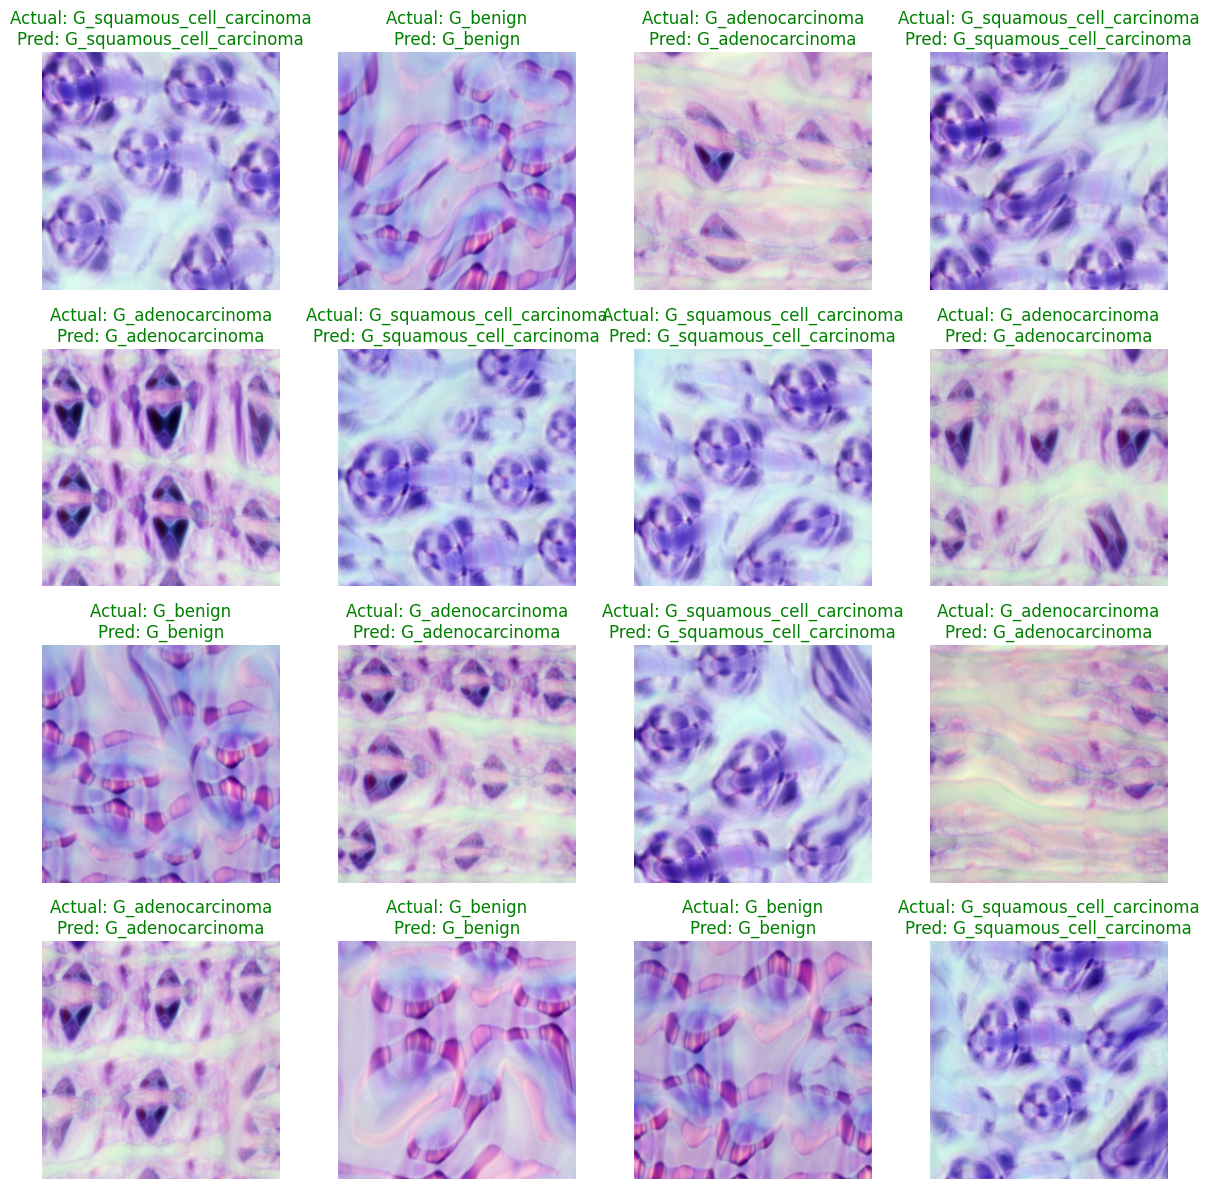

In [5]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split

# ------------------------------
# Data Preparation and Splitting
# ------------------------------

# Set data directories (update these paths as needed)
data_dir = '/kaggle/input/dcgan-images/dcgan_generated_images'
train_dir = '/kaggle/working/train'
val_dir = '/kaggle/working/val'
test_dir = '/kaggle/working/test'

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

classes = ['G_adenocarcinoma', 'G_benign', 'G_squamous_cell_carcinoma']
for subfolder in classes:
    os.makedirs(os.path.join(train_dir, subfolder), exist_ok=True)
    os.makedirs(os.path.join(val_dir, subfolder), exist_ok=True)
    os.makedirs(os.path.join(test_dir, subfolder), exist_ok=True)

def split_data(source_dir, train_dir, val_dir, test_dir, val_size=0.2, test_size=0.1):
    for label in classes:
        files = os.listdir(os.path.join(source_dir, label))
        train_files, val_test_files = train_test_split(files, test_size=val_size + test_size, random_state=42)
        val_files, test_files = train_test_split(val_test_files, test_size=test_size / (val_size + test_size), random_state=42)
        
        for file in train_files:
            shutil.copy(os.path.join(source_dir, label, file), os.path.join(train_dir, label, file))
        for file in val_files:
            shutil.copy(os.path.join(source_dir, label, file), os.path.join(val_dir, label, file))
        for file in test_files:
            shutil.copy(os.path.join(source_dir, label, file), os.path.join(test_dir, label, file))

# Run once to split the dataset
split_data(data_dir, train_dir, val_dir, test_dir)

# ------------------------------
# Data Transforms and Dataloaders
# ------------------------------

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val']),
    'test': datasets.ImageFolder(test_dir, data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False),
    'test': DataLoader(image_datasets['test'], batch_size=32, shuffle=False)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

# ------------------------------
# Helper Functions for Swin Transformer
# ------------------------------

def window_partition(x, window_size):
    """
    Partition input x into non-overlapping windows.
    x: (B, H, W, C)
    Returns: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    """
    Reconstruct feature map from windows.
    windows: (num_windows*B, window_size, window_size, C)
    Returns: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

# ------------------------------
# Simplified Swin Transformer Components
# ------------------------------

class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        """
        dim: input dimension
        window_size: int, window size (assumed square)
        num_heads: number of attention heads
        """
        super(WindowAttention, self).__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        
    def forward(self, x):
        """
        x: (B*num_windows, window_area, dim)
        """
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B_, num_heads, N, C//num_heads)
        q, k, v = qkv[0], qkv[1], qkv[2]   # each: (B_, num_heads, N, C//num_heads)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B_, num_heads, N, N)
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop=0.):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(drop)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=7, mlp_ratio=4.0, drop=0.):
        super(SwinTransformerBlock, self).__init__()
        self.window_size = window_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), drop=drop)
        
    def forward(self, x, H, W):
        """
        x: (B, L, dim) where L = H*W
        """
        shortcut = x
        x = self.norm1(x)
        B, L, C = x.shape
        x = x.view(B, H, W, C)
        
        # Partition windows
        windows = window_partition(x, self.window_size)  # (num_windows*B, window_size, window_size, C)
        windows = windows.view(-1, self.window_size * self.window_size, C)  # (num_windows*B, window_area, C)
        
        # Apply window-based multi-head self-attention
        attn_windows = self.attn(windows)  # (num_windows*B, window_area, C)
        
        # Merge windows back to feature map
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, H, W)  # (B, H, W, C)
        x = x.view(B, L, C)
        
        # Skip connection and MLP
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x

# ------------------------------
# Hybrid Model: EfficientNet + Swin Transformer
# ------------------------------

class HybridSwinEfficientNet(nn.Module):
    def __init__(self, num_classes, d_model=512, num_swin_blocks=2, window_size=7, num_heads=8):
        super(HybridSwinEfficientNet, self).__init__()
        # EfficientNet backbone (EfficientNet-B0)
        efficientnet = models.efficientnet_b0(pretrained=False)
        self.backbone = efficientnet.features  # Feature extractor
        # EfficientNet-B0 outputs feature maps with 1280 channels (for input size 224)
        self.project = nn.Conv2d(1280, d_model, kernel_size=1)  # Project to d_model
        
        self.num_swin_blocks = num_swin_blocks
        self.swin_blocks = nn.ModuleList([
            SwinTransformerBlock(dim=d_model, num_heads=num_heads, window_size=window_size)
            for _ in range(num_swin_blocks)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)
        
    def forward(self, x):
        # x: (B, 3, 224, 224)
        x = self.backbone(x)      # (B, 1280, 7, 7) for EfficientNet-B0 with 224 input
        x = self.project(x)       # (B, d_model, 7, 7)
        B, C, H, W = x.shape
        # Flatten spatial dimensions: (B, 49, d_model)
        x = x.flatten(2).transpose(1, 2)
        # Apply a series of Swin Transformer blocks
        for blk in self.swin_blocks:
            x = blk(x, H, W)
        x = self.norm(x)
        # Global average pooling over tokens
        x = x.mean(dim=1)
        x = self.classifier(x)
        return x

# ------------------------------
# Training and Evaluation Setup
# ------------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(class_names)
model = HybridSwinEfficientNet(num_classes=num_classes, d_model=512, num_swin_blocks=2, window_size=7, num_heads=8).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, criterion, optimizer, num_epochs=10):
    best_acc = 0.0
    best_model_wts = None
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs-1}')
        print('-' * 10)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
                
            running_loss = 0.0
            running_corrects = 0
            
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
                
    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
    return model

def test_model(model, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
    test_loss = running_loss / dataset_sizes['test']
    test_acc = running_corrects.double() / dataset_sizes['test']
    
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')

# ------------------------------
# Train and Evaluate the Model
# ------------------------------

model = train_model(model, criterion, optimizer, num_epochs=10)
test_model(model, criterion)

# ------------------------------
# Visualization Function
# ------------------------------

def show_random_test_predictions(model, dataloader, class_names, num_images=16):
    model.eval()
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    
    all_images = []
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_images.extend(inputs.cpu())
            all_labels.extend(labels.cpu())
            all_preds.extend(preds.cpu())
    
    combined = list(zip(all_images, all_labels, all_preds))
    random.shuffle(combined)
    selected_images = random.sample(combined, min(num_images, len(combined)))
    
    for idx, (img, label, pred) in enumerate(selected_images):
        ax = axes[idx]
        ax.axis('off')
        img = img.numpy().transpose((1, 2, 0))
        img = np.clip((img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])), 0, 1)
        ax.imshow(img)
        title = f'Actual: {class_names[label]}\nPred: {class_names[pred]}'
        ax.set_title(title, color='green' if class_names[label] == class_names[pred] else 'red')
    
    plt.tight_layout()
    plt.show()

# Visualize random predictions from the test set
show_random_test_predictions(model, dataloaders['test'], class_names, num_images=16)


Train classes: ['G_adenocarcinoma', 'G_benign', 'G_squamous_cell_carcinoma']
Test  classes: ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
Sizes: {'train': 1200, 'val': 402, 'test': 15000}
Epoch 0/9
----------
train Loss: 1.3161 Acc: 0.4833
val Loss: 1.2907 Acc: 0.3333
Epoch 1/9
----------
train Loss: 0.7928 Acc: 0.6100
val Loss: 0.5898 Acc: 0.6692
Epoch 2/9
----------
train Loss: 0.6960 Acc: 0.6458
val Loss: 0.4240 Acc: 0.9154
Epoch 3/9
----------
train Loss: 0.5047 Acc: 0.7717
val Loss: 0.2749 Acc: 0.8134
Epoch 4/9
----------
train Loss: 0.2682 Acc: 0.9008
val Loss: 0.0272 Acc: 0.9975
Epoch 5/9
----------
train Loss: 0.1460 Acc: 0.9542
val Loss: 0.0040 Acc: 1.0000
Epoch 6/9
----------
train Loss: 0.0954 Acc: 0.9683
val Loss: 0.0066 Acc: 1.0000
Epoch 7/9
----------
train Loss: 0.0433 Acc: 0.9875
val Loss: 0.0026 Acc: 1.0000
Epoch 8/9
----------
train Loss: 0.0785 Acc: 0.9775
val Loss: 0.0089 Acc: 1.0000
Epoch 9/9
----------
train Loss: 0.0696 Acc: 0.9825
val Loss: 0.0022 Acc:

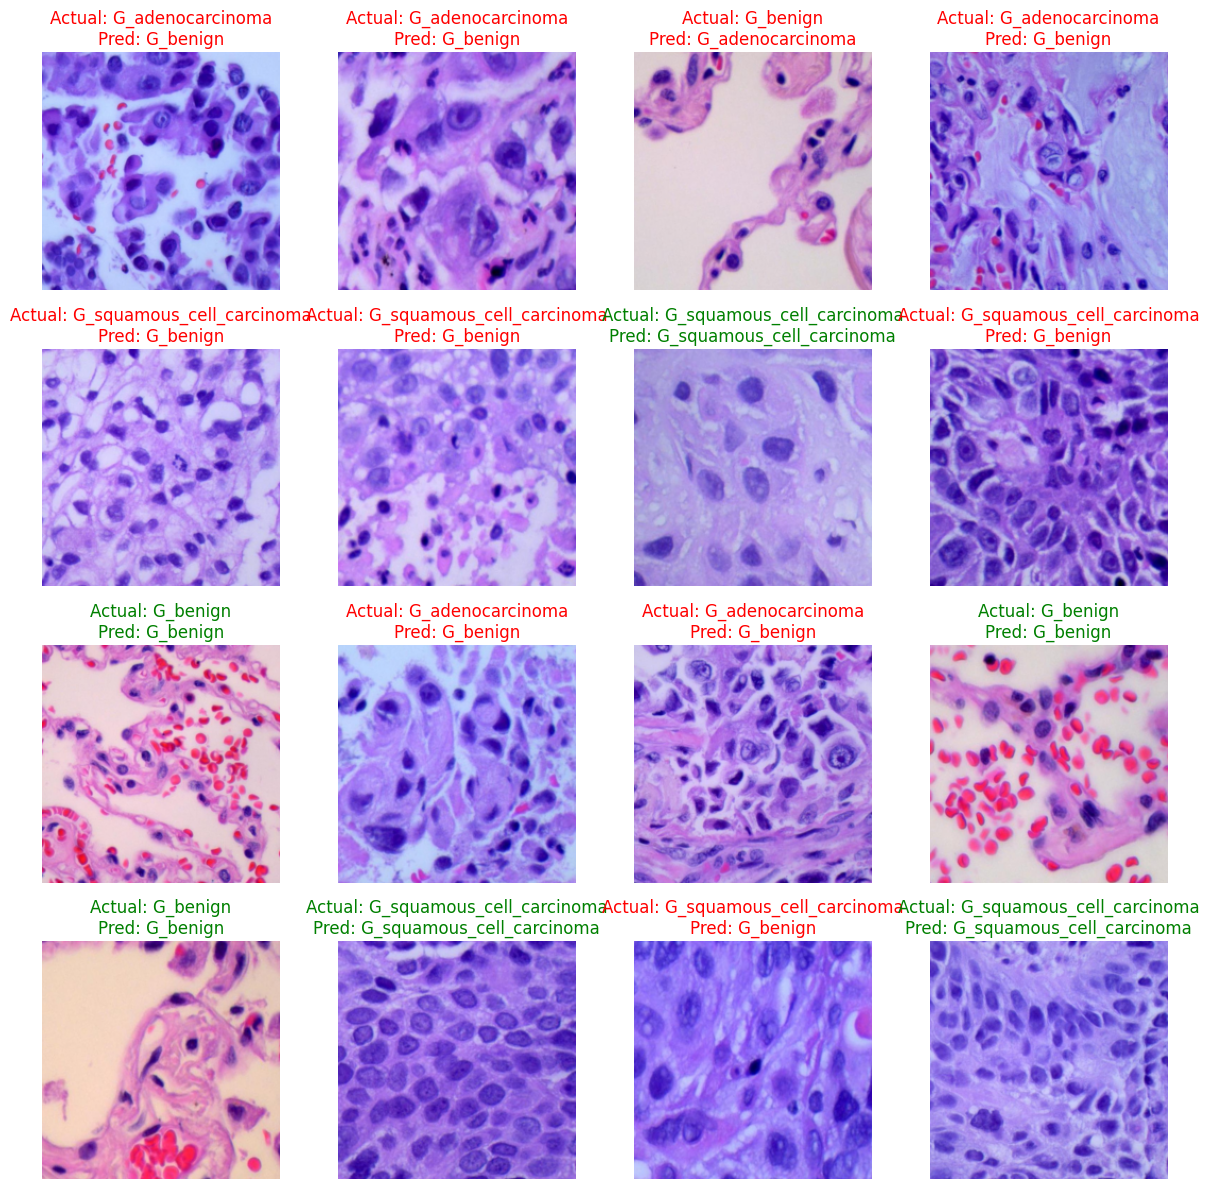

In [6]:
import os
import shutil
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 1. Paths
gan_dir       = '/kaggle/input/dcgan-images/dcgan_generated_images'
real_dir      = '/kaggle/input/lung-cancer-histopathological-images'
work_dir      = '/kaggle/working'
train_dir     = os.path.join(work_dir, 'train')
val_dir       = os.path.join(work_dir, 'val')

# 2. Make train/val dirs for GAN images
classes = ['G_adenocarcinoma', 'G_benign', 'G_squamous_cell_carcinoma']
for d in [train_dir, val_dir]:
    for c in classes:
        os.makedirs(os.path.join(d, c), exist_ok=True)

# 3. Split GAN images (80/20) into train/val
def split_gan( src, train_dst, val_dst, val_frac=0.2, seed=42 ):
    for c in classes:
        imgs = os.listdir(os.path.join(src, c))
        train_imgs, val_imgs = train_test_split(imgs, test_size=val_frac, random_state=seed)
        for fn in train_imgs:
            shutil.copy(os.path.join(src, c, fn), os.path.join(train_dst, c, fn))
        for fn in val_imgs:
            shutil.copy(os.path.join(src, c, fn), os.path.join(val_dst, c, fn))

split_gan(gan_dir, train_dir, val_dir)

# 4. Transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
    # real test set gets the same transforms as val
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),
}

# 5. Datasets & Loaders
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val'  : datasets.ImageFolder(val_dir,   data_transforms['val']),
    # point test at the real dataset (no G_ prefix in subfolders)
    'test' : datasets.ImageFolder(real_dir,  data_transforms['test'])
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32,
                  shuffle=(x=='train'))
    for x in ['train','val','test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train','val','test']}
class_names   = image_datasets['train'].classes   # ['G_adenocarcinoma',...]
test_names    = image_datasets['test'].classes    # ['adenocarcinoma',...]

print("Train classes:", class_names)
print("Test  classes:", test_names)
print("Sizes:", dataset_sizes)

# ------------------------------
# Helper Functions for Swin Transformer
# ------------------------------

def window_partition(x, window_size):
    """
    Partition input x into non-overlapping windows.
    x: (B, H, W, C)
    Returns: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    """
    Reconstruct feature map from windows.
    windows: (num_windows*B, window_size, window_size, C)
    Returns: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

# ------------------------------
# Simplified Swin Transformer Components
# ------------------------------

class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        """
        dim: input dimension
        window_size: int, window size (assumed square)
        num_heads: number of attention heads
        """
        super(WindowAttention, self).__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        
    def forward(self, x):
        """
        x: (B*num_windows, window_area, dim)
        """
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B_, num_heads, N, C//num_heads)
        q, k, v = qkv[0], qkv[1], qkv[2]   # each: (B_, num_heads, N, C//num_heads)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B_, num_heads, N, N)
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop=0.):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(drop)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=7, mlp_ratio=4.0, drop=0.):
        super(SwinTransformerBlock, self).__init__()
        self.window_size = window_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), drop=drop)
        
    def forward(self, x, H, W):
        """
        x: (B, L, dim) where L = H*W
        """
        shortcut = x
        x = self.norm1(x)
        B, L, C = x.shape
        x = x.view(B, H, W, C)
        
        # Partition windows
        windows = window_partition(x, self.window_size)  # (num_windows*B, window_size, window_size, C)
        windows = windows.view(-1, self.window_size * self.window_size, C)  # (num_windows*B, window_area, C)
        
        # Apply window-based multi-head self-attention
        attn_windows = self.attn(windows)  # (num_windows*B, window_area, C)
        
        # Merge windows back to feature map
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, H, W)  # (B, H, W, C)
        x = x.view(B, L, C)
        
        # Skip connection and MLP
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x

# ------------------------------
# Hybrid Model: EfficientNet + Swin Transformer
# ------------------------------

class HybridSwinEfficientNet(nn.Module):
    def __init__(self, num_classes, d_model=512, num_swin_blocks=2, window_size=7, num_heads=8):
        super(HybridSwinEfficientNet, self).__init__()
        # EfficientNet backbone (EfficientNet-B0)
        efficientnet = models.efficientnet_b0(pretrained=False)
        self.backbone = efficientnet.features  # Feature extractor
        # EfficientNet-B0 outputs feature maps with 1280 channels (for input size 224)
        self.project = nn.Conv2d(1280, d_model, kernel_size=1)  # Project to d_model
        
        self.num_swin_blocks = num_swin_blocks
        self.swin_blocks = nn.ModuleList([
            SwinTransformerBlock(dim=d_model, num_heads=num_heads, window_size=window_size)
            for _ in range(num_swin_blocks)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)
        
    def forward(self, x):
        # x: (B, 3, 224, 224)
        x = self.backbone(x)      # (B, 1280, 7, 7) for EfficientNet-B0 with 224 input
        x = self.project(x)       # (B, d_model, 7, 7)
        B, C, H, W = x.shape
        # Flatten spatial dimensions: (B, 49, d_model)
        x = x.flatten(2).transpose(1, 2)
        # Apply a series of Swin Transformer blocks
        for blk in self.swin_blocks:
            x = blk(x, H, W)
        x = self.norm(x)
        # Global average pooling over tokens
        x = x.mean(dim=1)
        x = self.classifier(x)
        return x

# ------------------------------
# Training and Evaluation Setup
# ------------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(class_names)
model = HybridSwinEfficientNet(num_classes=num_classes, d_model=512, num_swin_blocks=2, window_size=7, num_heads=8).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, criterion, optimizer, num_epochs=10):
    best_acc = 0.0
    best_model_wts = None
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs-1}')
        print('-' * 10)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
                
            running_loss = 0.0
            running_corrects = 0
            
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
                
    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
    return model

def test_model(model, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
    test_loss = running_loss / dataset_sizes['test']
    test_acc = running_corrects.double() / dataset_sizes['test']
    
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')

# ------------------------------
# Train and Evaluate the Model
# ------------------------------

model = train_model(model, criterion, optimizer, num_epochs=10)
test_model(model, criterion)

# ------------------------------
# Visualization Function
# ------------------------------

def show_random_test_predictions(model, dataloader, class_names, num_images=16):
    model.eval()
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    
    all_images = []
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_images.extend(inputs.cpu())
            all_labels.extend(labels.cpu())
            all_preds.extend(preds.cpu())
    
    combined = list(zip(all_images, all_labels, all_preds))
    random.shuffle(combined)
    selected_images = random.sample(combined, min(num_images, len(combined)))
    
    for idx, (img, label, pred) in enumerate(selected_images):
        ax = axes[idx]
        ax.axis('off')
        img = img.numpy().transpose((1, 2, 0))
        img = np.clip((img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])), 0, 1)
        ax.imshow(img)
        title = f'Actual: {class_names[label]}\nPred: {class_names[pred]}'
        ax.set_title(title, color='green' if class_names[label] == class_names[pred] else 'red')
    
    plt.tight_layout()
    plt.show()

# Visualize random predictions from the test set
show_random_test_predictions(model, dataloaders['test'], class_names, num_images=16)
